## Visualisation

In [2]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

### Loading Superstore Dataset for analysis
The CSV file is saved in a different text format than what pandas expects.  
By default, pandas tries to read files as **UTF‑8**,but the file is in another format (`latin1`).  

To fix it,we are telling pandas the right format when loading:

df = pd.read_csv("superstore_dataset.csv", encoding="latin1")

In [3]:
df = pd.read_csv("superstore_dataset.csv", encoding="latin1")
df.head()

,Row_ID,Order_ID,Order_Date,Ship_Date,Ship_Mode,Customer_ID,Customer_Name,Segment,Country,City,State,Postal_Code,Region,Product_ID,Category,Sub_Category,Product_Name,Sales
0,1,CA-2017-152156,8/11/2017,11/11/2017,Second Class,CG-12520,Claire Gute,Consumer,United States,Henderson,Kentucky,42420.0,South,FUR-BO-10001798,Furniture,Bookcases,Bush Somerset Collection Bookcase,261.9600
1,2,CA-2017-152156,8/11/2017,11/11/2017,Second Class,CG-12520,Claire Gute,Consumer,United States,Henderson,Kentucky,42420.0,South,FUR-CH-10000454,Furniture,Chairs,"Hon Deluxe Fabric Upholstered Stacking Chairs,...",731.9400
2,3,CA-2017-138688,12/6/2017,16/06/2017,Second Class,DV-13045,Darrin Van Huff,Corporate,United States,Los Angeles,California,90036.0,West,OFF-LA-10000240,Office Supplies,Labels,Self-Adhesive Address Labels for Typewriters b...,14.6200
3,4,US-2016-108966,11/10/2016,18/10/2016,Standard Class,SO-20335,Sean O Donnel,Consumer,United States,Fort Lauderdale,Florida,33311.0,South,FUR-TA-10000577,Furniture,Tables,Bretford CR4500 Series Slim Rectangular Table,957.5775
4,5,US-2016-108966,11/10/2016,18/10/2016,Standard Class,SO-20335,Sean O Donnel,Consumer,United States,Fort Lauderdale,Florida,33311.0,South,OFF-ST-10000760,Office Supplies,Storage,Eldon Fold N Roll Cart System,22.3680


### Average Sales by Sub-Category

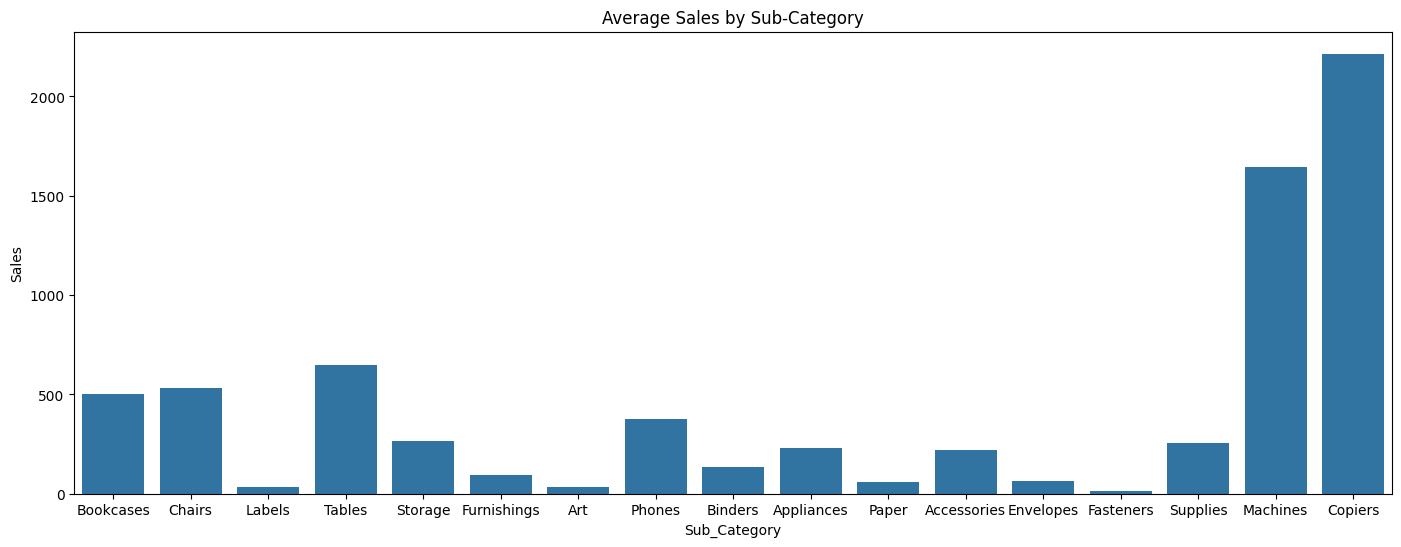

In [4]:
plt.figure(figsize=(17,6))
sns.barplot(y="Sales",x="Sub_Category" , data=df , errorbar=None)

plt.title("Average Sales by Sub-Category")
plt.xlabel("Sub_Category")
plt.ylabel("Sales")
plt.show()

### Total Sales by Category

Text(0.5, 1.0, 'Total Sales by Category')

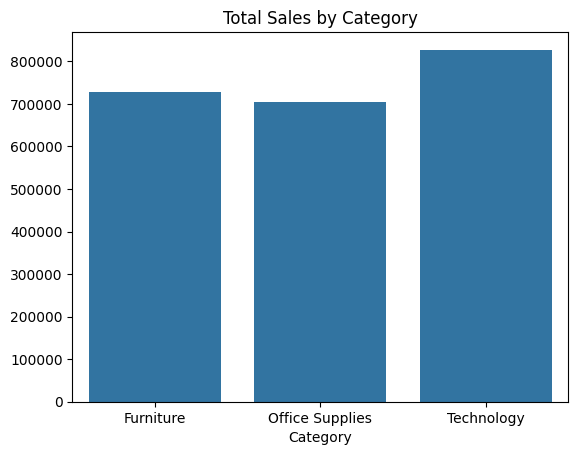

In [5]:
data = df.groupby("Category")["Sales"].sum()

sns.barplot(x=data.index, y=data.values)
plt.title("Total Sales by Category")

**Insight:**

* Technology has the highest total sales among the three categories.

### Time-Based Sales Analysis

Sales are analyzed over time to identify changes and fluctuations in monthly sales performance.

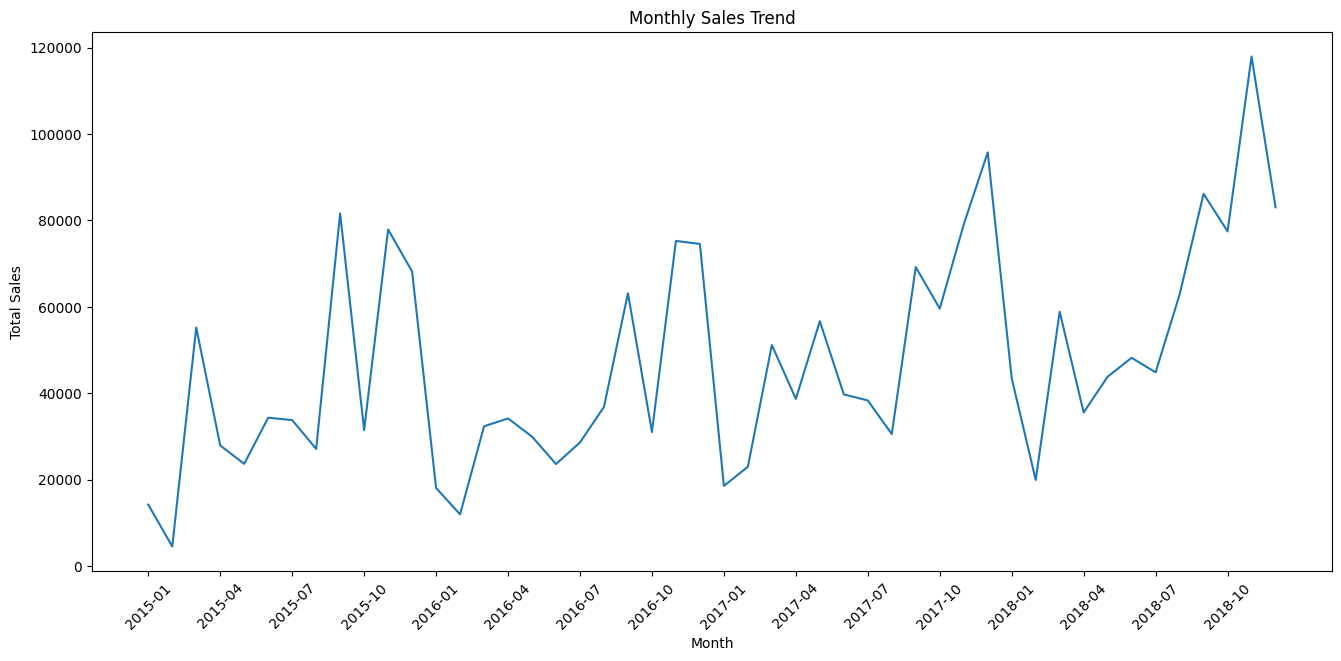

In [11]:
df["Order_Date"] = pd.to_datetime(df["Order_Date"], dayfirst=True)
monthly_sales = df.groupby( df["Order_Date"].dt.to_period("M"))["Sales"].sum()

monthly_sales.head()
df["Month"] = df["Order_Date"].dt.to_period("M")
monthly_sales=df.groupby("Month")["Sales"].sum()
monthly_sales.head()

plt.figure(figsize=(16, 7))

sns.lineplot(
    x=monthly_sales.index.astype(str),
    y=monthly_sales.values
)

plt.title("Monthly Sales Trend")
plt.xlabel("Month")
plt.ylabel("Total Sales")

plt.xticks(
    range(0, len(monthly_sales), 3),
    monthly_sales.index.astype(str)[::3],
    rotation=45
)

plt.show()

### Key Insights

- Sales show **significant month-to-month fluctuations**, indicating an inconsistent sales pattern.
- **November 2017** recorded the highest sales, at approximately **118K**.
- Sales showed a **strong upward trend toward the end of 2017**, particularly from September to November.
- **February 2015** recorded the lowest sales, at approximately **5K**.
- The fluctuations may indicate the influence of **seasonality, promotions, or other external factors**.

### Category and Regional Performance

#### Total Sales by Category and Region

This visualization compares total sales across product categories and regions to identify differences in category performance between regions.

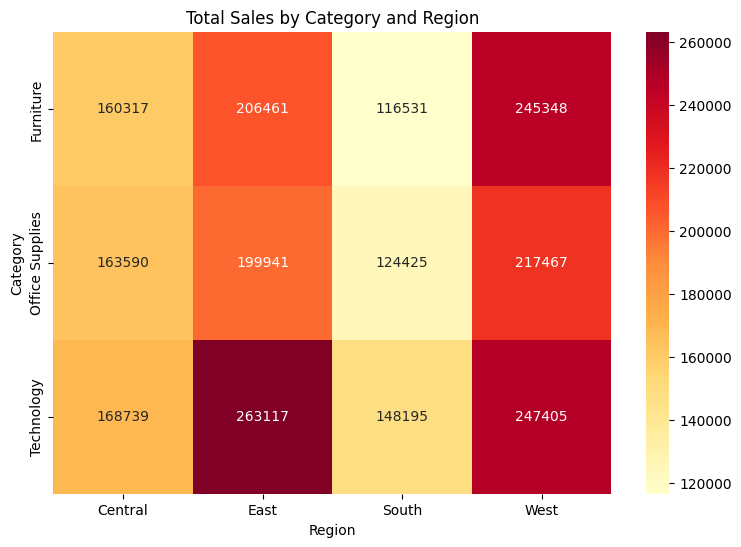

In [7]:
total_sales=df.groupby(["Category","Region"])["Sales"].sum().unstack()
total_sales
plt.figure(figsize=(9, 6))

sns.heatmap(
    total_sales,
    annot=True,
    fmt=".0f",
    cmap="YlOrRd"
)

plt.title("Total Sales by Category and Region")
plt.xlabel("Region")
plt.ylabel("Category")

plt.show()

**Insight:**

- The **East region** has the highest sales for **Technology**, with total sales of approximately **263,117**.
- The **West region** has the highest sales for **Furniture**, with approximately **245,348** in total sales.
- **Technology** performs strongly across all regions and has the highest sales in East.
- The **South region** has the lowest sales across all three categories compared with the other regions.
- The highest overall category-region combination is **Technology in the East**, while the lowest is **Furniture in the South**.

### Customer Value Analysis

### Top 10 Customers by Total Sales

This visualization identifies the top 10 customers based on their total sales contribution. It helps highlight high-value customers who contribute significantly to overall revenue,and if possible then to provide extra discount.

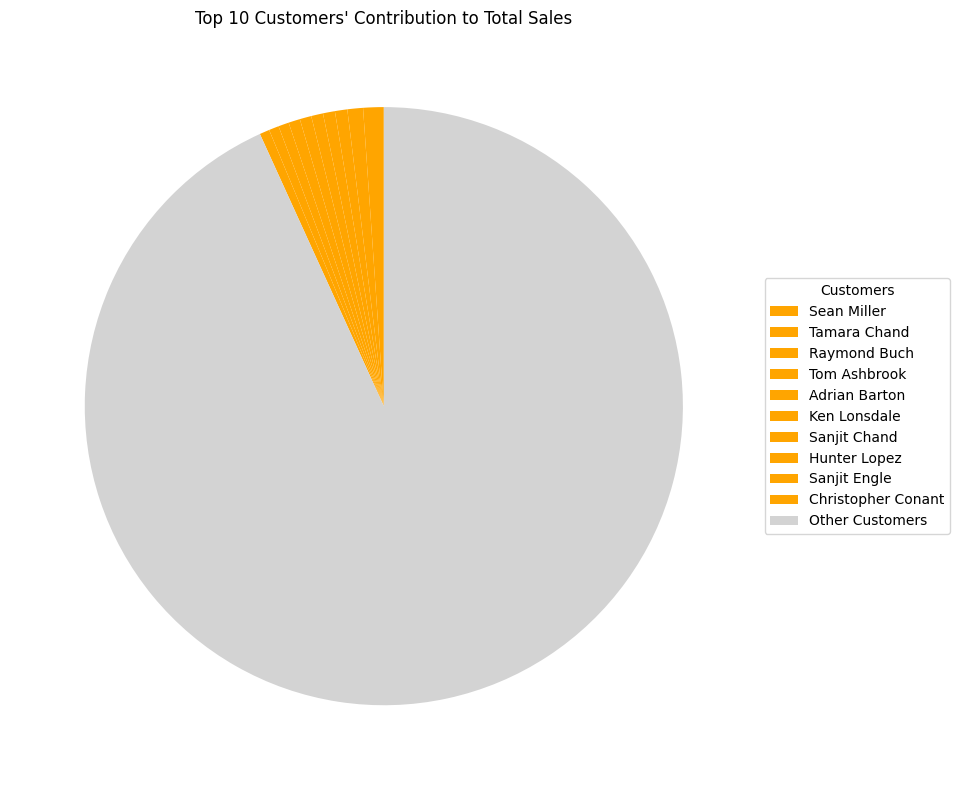

In [8]:
top_customers=df.groupby("Customer_Name")["Sales"].sum().sort_values(ascending=False).head(10)

other_sales = df["Sales"].sum() - top_customers.sum()

pie_data = pd.concat([
    top_customers,
    pd.Series({"Other Customers": other_sales})
])

colors = ["orange"] * 10 + ["lightgray"]

plt.figure(figsize=(10, 8))

wedges, _ = plt.pie(
    pie_data.values,
    startangle=90,
    colors=colors
)

plt.legend(
    wedges,
    pie_data.index,
    title="Customers",
    loc="center left",
    bbox_to_anchor=(1, 0.5)
)

plt.title("Top 10 Customers' Contribution to Total Sales")

plt.tight_layout()
plt.show()

### Insights
* Other Customers generate 93.2% of total sales.
* Top 10 customers contribute only 6.8% of total sales.
* Sales are widely distributed, with low dependency on individual customers.
* The business has a broad customer base, reducing reliance on a few high-value customers.

### Shipping Time Analysis

#### Distribution of Shipping Time

The shipping time is calculated as the number of days between the order date and ship date. This visualization helps understand the typical shipping duration and identify unusually long shipping times.

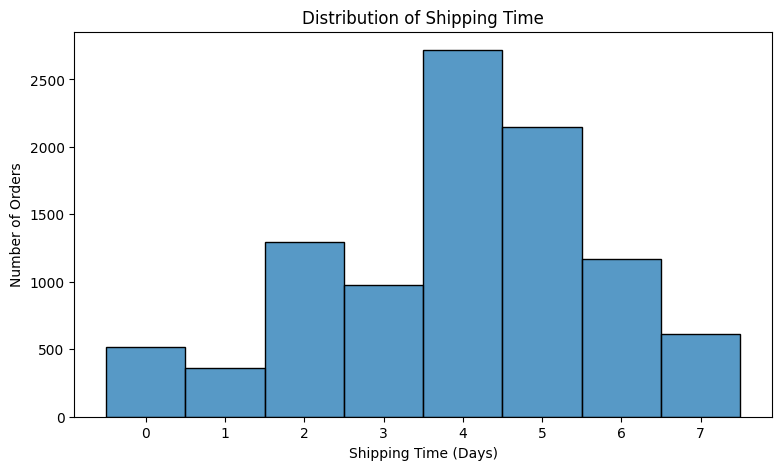

In [9]:
df["Order_Date"] = pd.to_datetime(df["Order_Date"], dayfirst=True)
df["Ship_Date"] = pd.to_datetime(df["Ship_Date"], dayfirst=True)
df["Shipping_Days"] = (
    df["Ship_Date"] - df["Order_Date"]
).dt.days
df["Shipping_Days"].value_counts().sort_index()

plt.figure(figsize=(9, 5))

sns.histplot(
    data=df,
    x="Shipping_Days",
    bins=8,
    discrete=True
)

plt.title("Distribution of Shipping Time")
plt.xlabel("Shipping Time (Days)")
plt.ylabel("Number of Orders")

plt.show()

### Insight

- **4 days is the most common shipping time**, with around **2,718 orders**.
- Most orders are shipped within **2–6 days**.
- **1 day** has the fewest orders, with **363 orders**.
- Only a small number of orders are shipped immediately (**0 days: 514 orders**).


### Order Activity by Day of Week

#### Number of Orders by Day of Week

This visualization analyzes the distribution of orders across the days of the week to identify when order activity is highest.

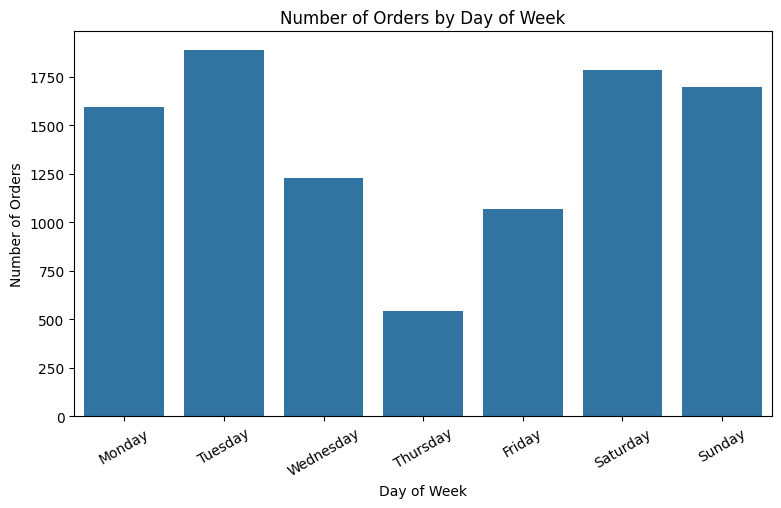

In [10]:
df["Day_of_Week"] = df["Order_Date"].dt.day_name()

day_order = [
    "Monday", "Tuesday", "Wednesday",
    "Thursday", "Friday", "Saturday", "Sunday"
]

orders_by_day = (
    df["Day_of_Week"]
    .value_counts()
    .reindex(day_order)
)

plt.figure(figsize=(9, 5))

sns.barplot(
    x=orders_by_day.index,
    y=orders_by_day.values,
    errorbar=None
)

plt.title("Number of Orders by Day of Week")
plt.xlabel("Day of Week")
plt.ylabel("Number of Orders")

plt.xticks(rotation=30)
plt.show()

### Insight

- **Tuesday has the highest number of orders**, with approximately **1,885 orders**.
- **Thursday has the lowest order activity**, with approximately **540 orders**.
- Order activity is generally higher on **Monday, Tuesday, Saturday, and Sunday**, while **Wednesday–Friday** show lower activity.

### Business Recommendation

The company can focus promotions and marketing campaigns around **lower-activity days**, especially Thursday, to increase order volume.

## Conclusion

The visualizations provided a clear overview of sales performance, customer contribution, regional and category trends, shipping patterns, and order activity. These findings help identify high-performing areas, potential improvement areas, and opportunities for better business decisions.